In [2]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("ressources")

df_reservations = pd.read_csv(DATA_DIR / "reservations_train.csv")
# test_df = pd.read_csv(DATA_DIR / "reservations_test.csv")
# data_dict = pd.read_csv(DATA_DIR / "data_dictionary.csv")

print("Train :", df_reservations.shape)
# print("Test  :", test_df.shape)

Train : (8000, 34)


### Étape 1: EDA et Préparation

#### Analyse de la Variable Cible: `reservation_annulee`

La variable cible pour cette analyse est `reservation_annulee`, qui indique si une réservation a été annulée (1) ou non (0).

In [3]:
# Vérifier le type de données de la variable cible
display(df_reservations['reservation_annulee'].dtype)

# Vérifier les valeurs manquantes dans la variable cible
display(df_reservations['reservation_annulee'].isnull().sum())

# Afficher la distribution de la variable cible
display(df_reservations['reservation_annulee'].value_counts())

dtype('int64')

np.int64(0)

reservation_annulee
0    5933
1    2067
Name: count, dtype: int64

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualiser la distribution de la variable cible
plt.figure(figsize=(6, 4))
sns.countplot(x='reservation_annulee', data=df_reservations, palette='viridis')
plt.title('Distribution des Réservations Annulées (0=Non, 1=Oui)')
plt.xlabel('Réservation Annulée')
plt.ylabel('Nombre de Réservations')
plt.xticks(ticks=[0, 1], labels=['Non Annulée', 'Annulée'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

ModuleNotFoundError: No module named 'matplotlib'

#### Justification des Traitements Appliqués à la Cible

Les étapes d'analyse de la variable cible `reservation_annulee` ont montré que :

1.  **Type de Données :** La variable est de type `int64`, ce qui est approprié pour une variable binaire (0 ou 1).
2.  **Valeurs Manquantes :** Il n'y a pas de valeurs manquantes (0 `null` values), donc aucun traitement spécifique n'est nécessaire à ce stade pour les valeurs manquantes.
3.  **Distribution :** La distribution de la variable cible sera examinée pour détecter un éventuel déséquilibre entre les classes 'Non Annulée' et 'Annulée'. Si un déséquilibre important est constaté, des techniques de rééchantillonnage (suréchantillonnage, sous-échantillonnage) pourraient être envisagées lors de la phase de modélisation pour garantir que le modèle ne soit pas biaisé vers la classe majoritaire.

Pour l'instant, la variable cible `reservation_annulee` est prête à être utilisée telle quelle pour les analyses ultérieures.

In [ ]:
# Calculer le pourcentage de valeurs manquantes pour chaque colonne
missing_values_pct = df_reservations.isnull().sum() / len(df_reservations) * 100

# Afficher les colonnes avec des valeurs manquantes et leur pourcentage
missing_columns = missing_values_pct[missing_values_pct > 0].sort_values(ascending=False)
print("Pourcentage de valeurs manquantes par colonne :")
display(missing_columns)

Pourcentage de valeurs manquantes par colonne :


,0
agent_id,41.9250
enfants,4.4375
prix_moyen_nuit_eur,2.4125
marche_origine,2.3875
demandes_speciales,1.9625


### Imputation des Valeurs Manquantes

Nous allons appliquer les stratégies d'imputation discutées précédemment.

In [ ]:
# Imputation pour 'agent_id': Remplacer les NaN par 'Non_spécifié'
df_reservations['agent_id'] = df_reservations['agent_id'].fillna('Non_spécifié')

# Imputation pour 'enfants' et 'demandes_speciales': Remplacer les NaN par 0
df_reservations['enfants'] = df_reservations['enfants'].fillna(0)
df_reservations['demandes_speciales'] = df_reservations['demandes_speciales'].fillna(0)

# Imputation pour 'prix_moyen_nuit_eur': Remplacer les NaN par la médiane
median_prix_moyen = df_reservations['prix_moyen_nuit_eur'].median()
df_reservations['prix_moyen_nuit_eur'] = df_reservations['prix_moyen_nuit_eur'].fillna(median_prix_moyen)

# Imputation pour 'marche_origine': Remplacer les NaN par le mode
mode_marche_origine = df_reservations['marche_origine'].mode()[0]
df_reservations['marche_origine'] = df_reservations['marche_origine'].fillna(mode_marche_origine)

print("Vérification des valeurs manquantes après imputation :")
display(df_reservations.isnull().sum()[df_reservations.isnull().sum() > 0])

Vérification des valeurs manquantes après imputation :


,0


### Analyse des Distributions et Détection des Valeurs Atypiques

Maintenant que les données sont nettoyées de leurs valeurs manquantes, nous allons examiner les distributions des différentes caractéristiques pour mieux les comprendre et identifier les éventuelles valeurs atypiques (outliers).

#### 1. Analyse des Variables Numériques

Nous allons visualiser la distribution de chaque variable numérique à l'aide d'histograms et de boxplots pour observer leur forme, leur asymétrie et détecter les valeurs aberrantes.

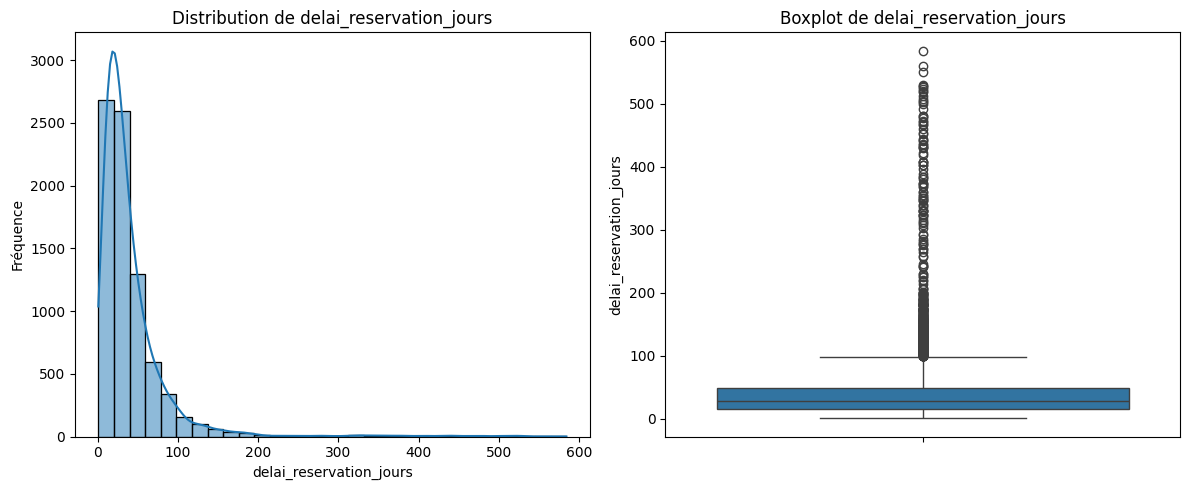

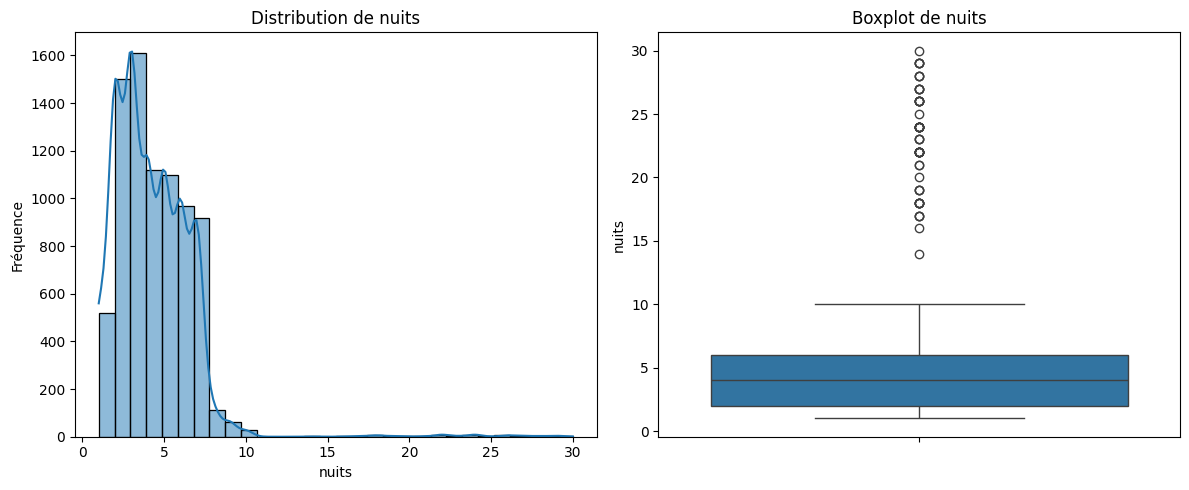

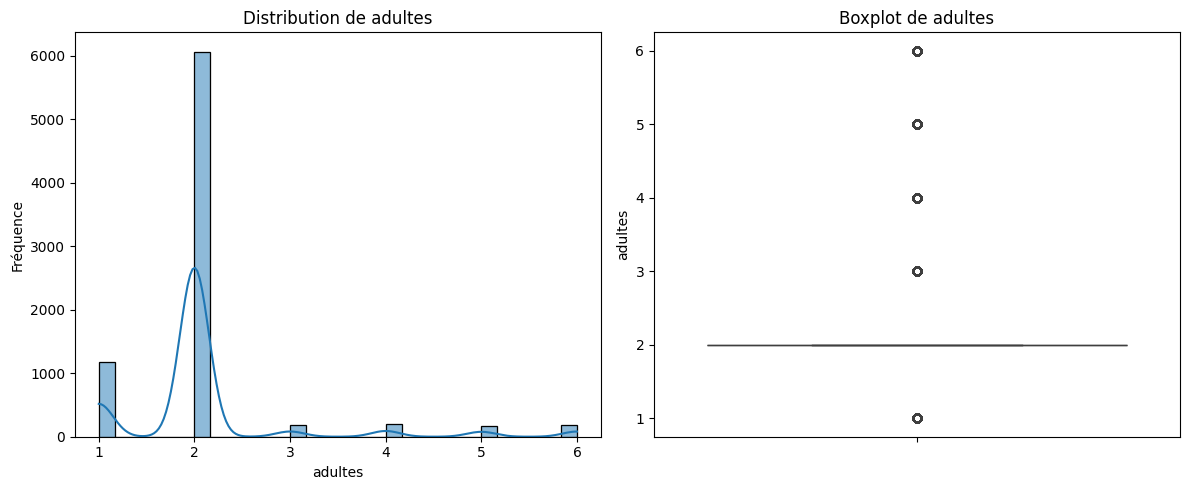

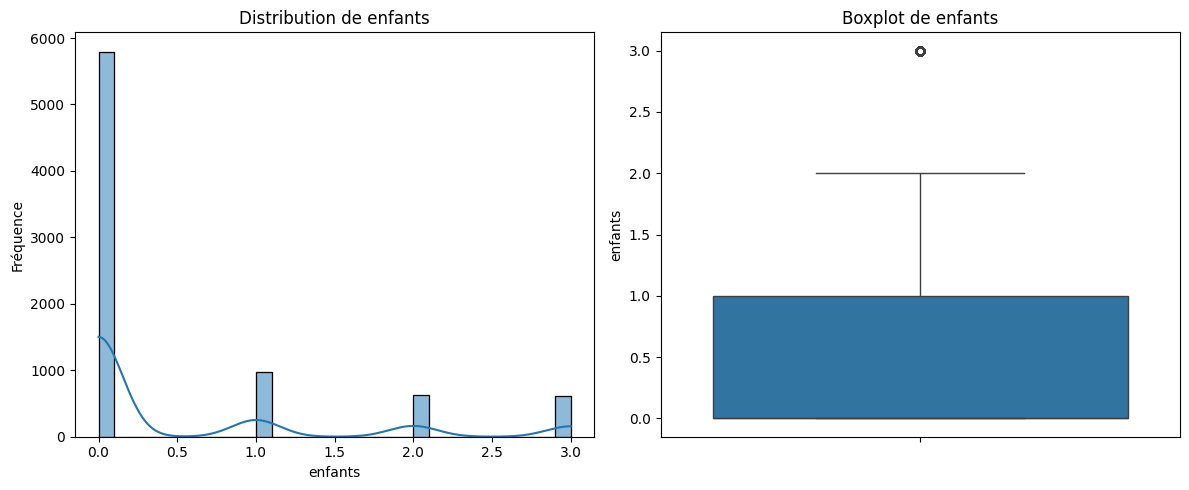

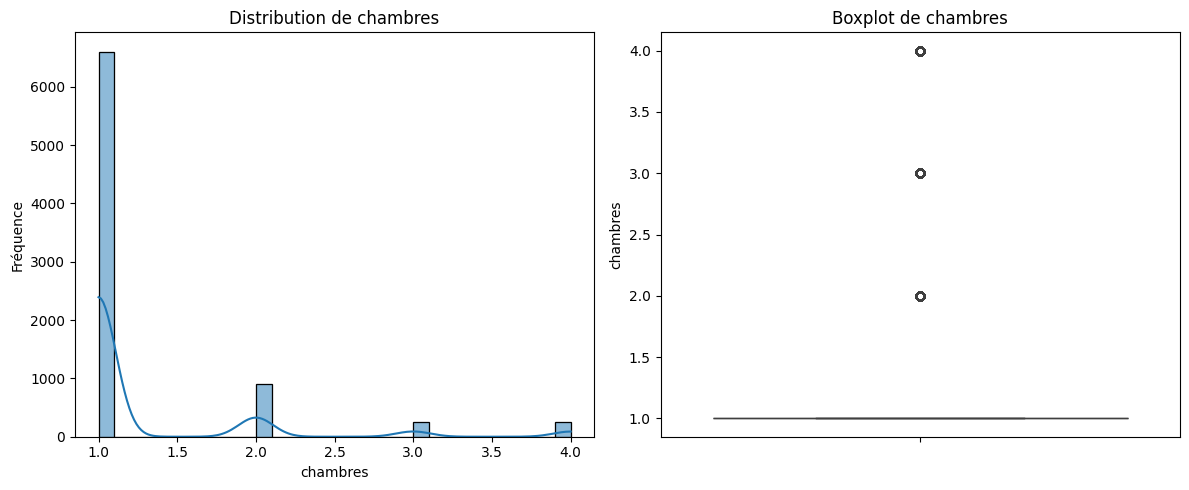

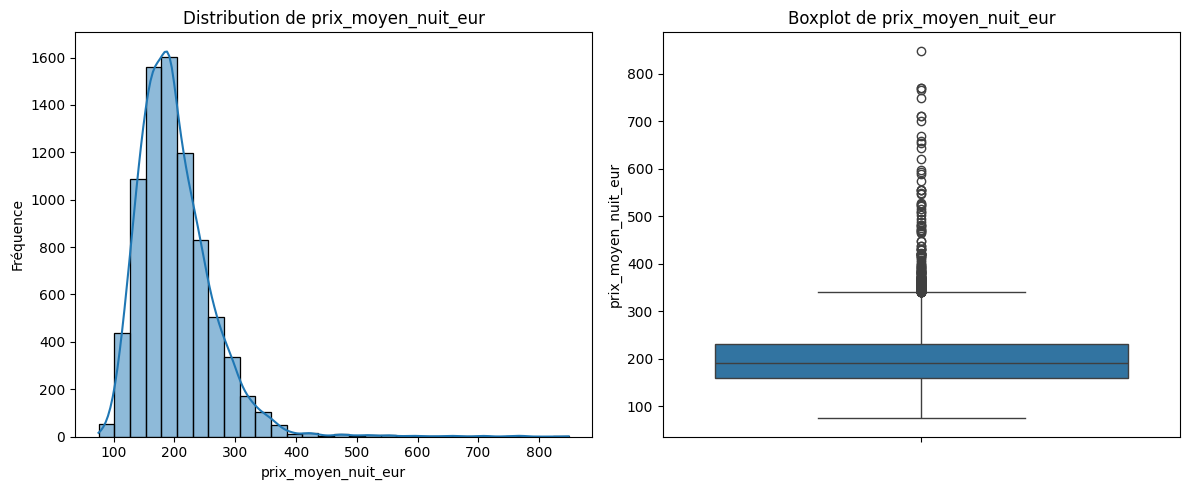

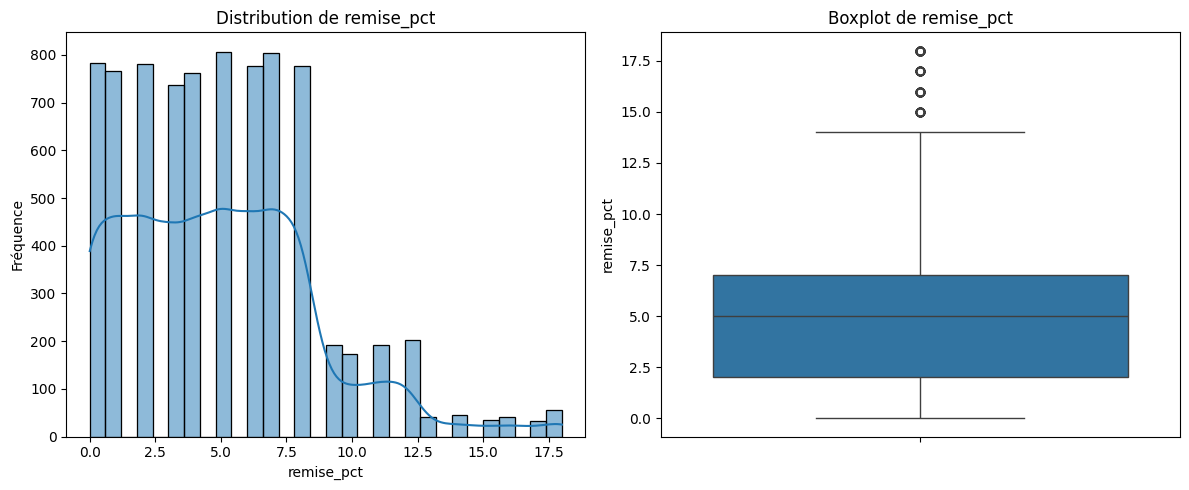

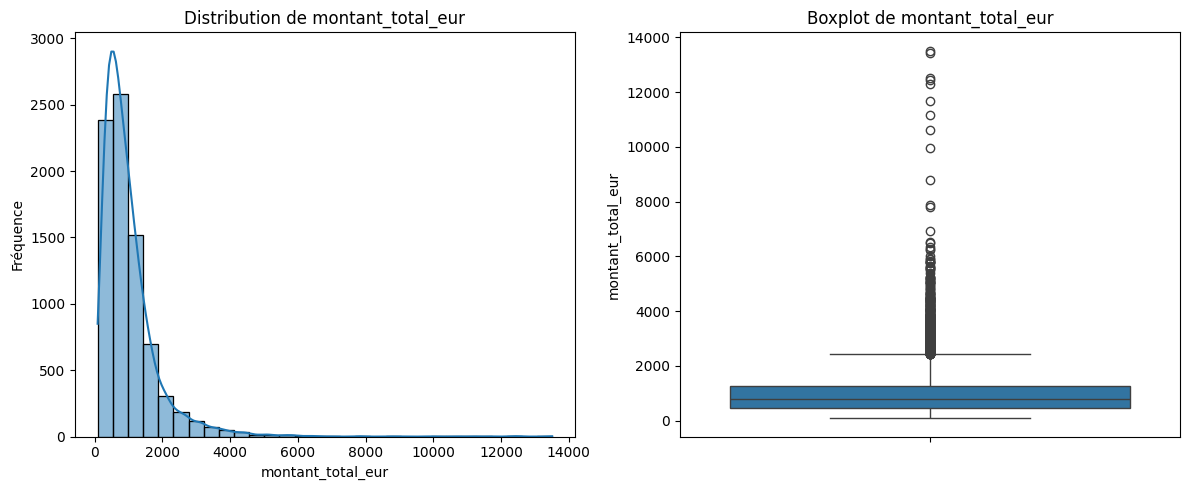

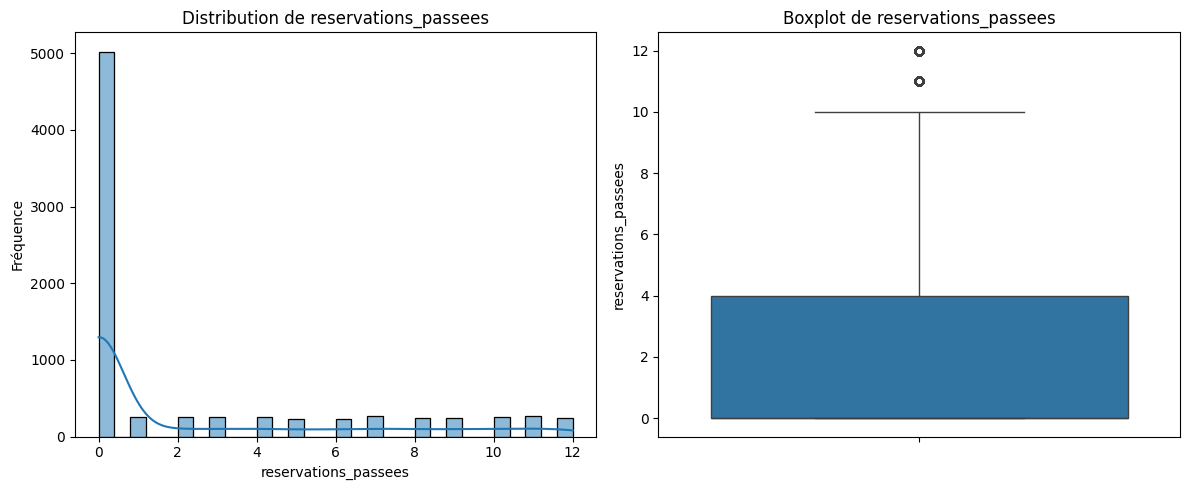

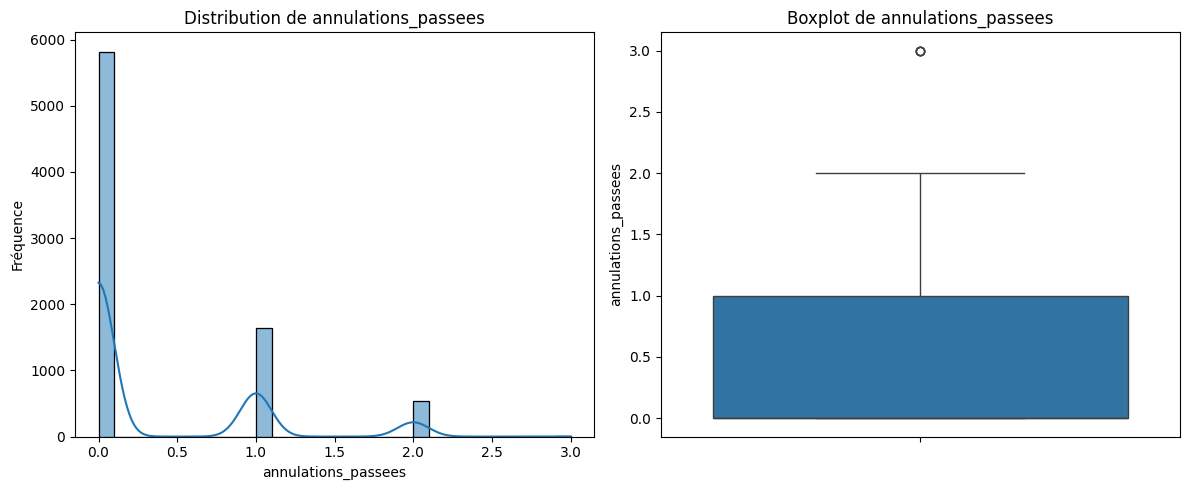

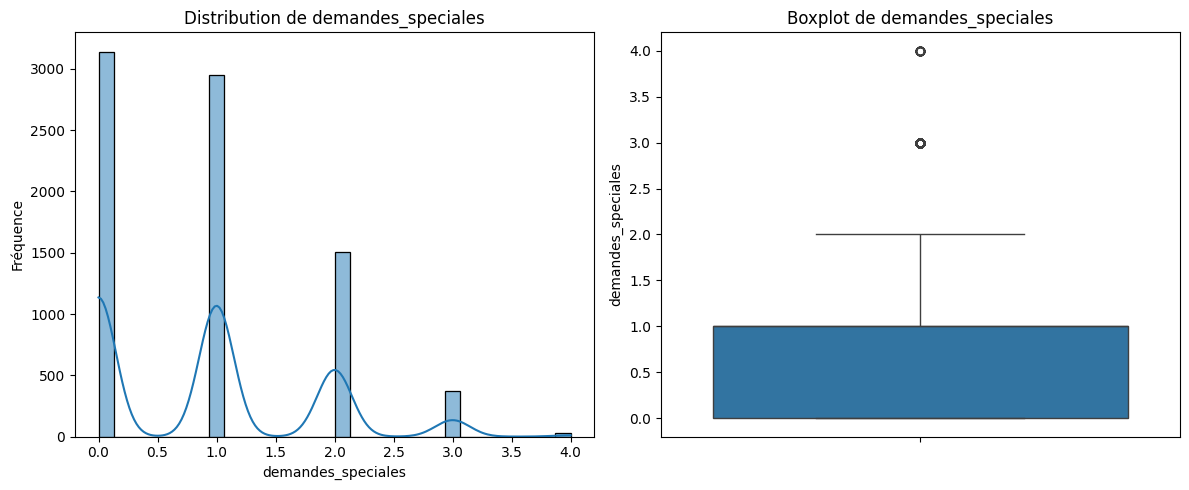

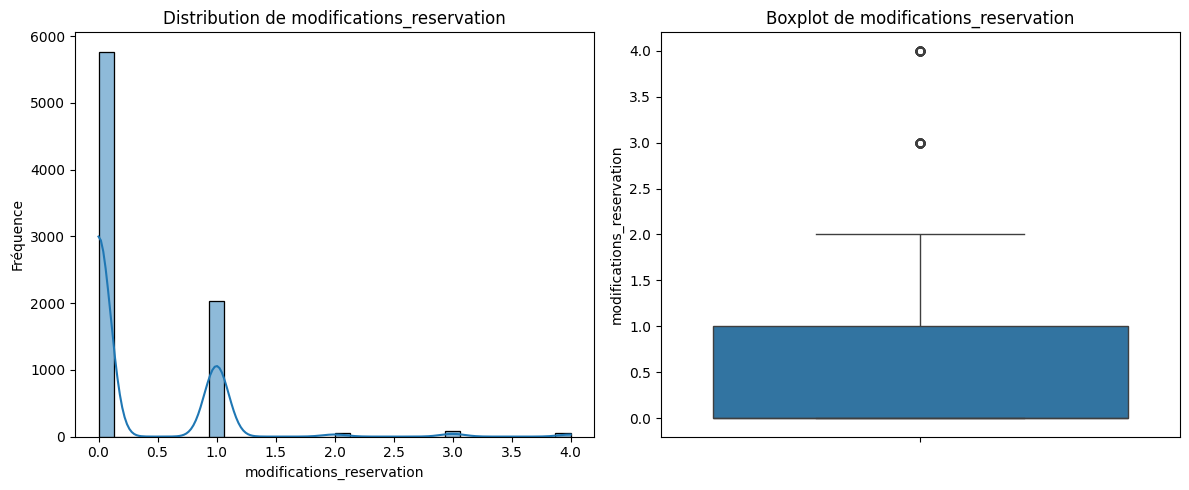

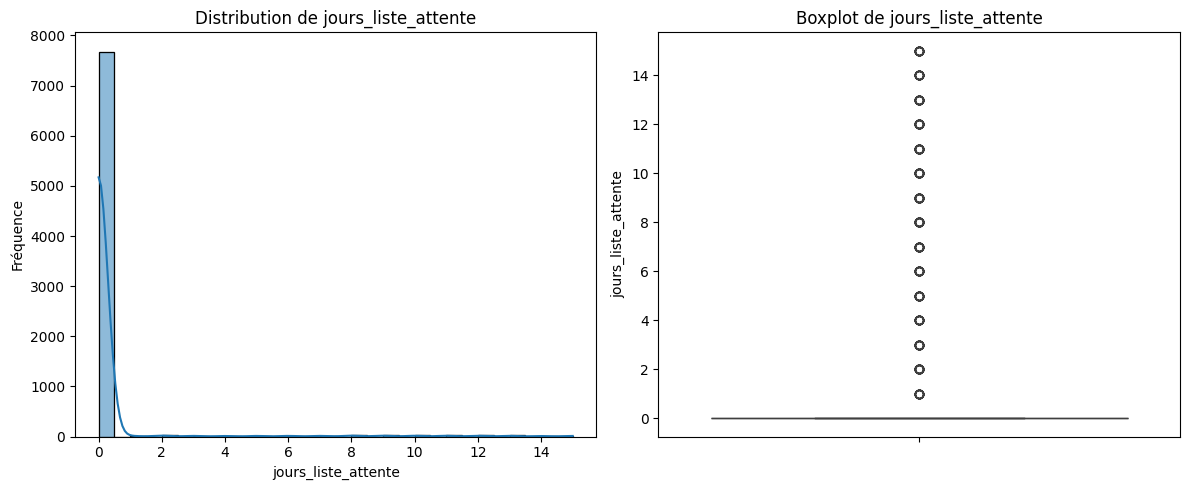

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identifier les colonnes numériques (excluant les IDs et la cible déjà analysée)
numerical_cols = df_reservations.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in ['reservation_annulee', 'categorie_hotel', 'arrivee_weekend', 'evenement_majeur', 'haute_saison_regionale']]

# Filtrer les colonnes qui pourraient être considérées comme binaires/quasi-binaires
# 'categorie_hotel', 'evenement_majeur', 'haute_saison_regionale', 'arrivee_weekend' sont plutôt catégorielles/binaires

for col in numerical_cols:
    plt.figure(figsize=(12, 5))

    # Histogramme pour la distribution
    plt.subplot(1, 2, 1) # 1 ligne, 2 colonnes, 1er plot
    sns.histplot(df_reservations[col], kde=True, bins=30)
    plt.title(f'Distribution de {col}')
    plt.xlabel(col)
    plt.ylabel('Fréquence')

    # Boxplot pour les outliers
    plt.subplot(1, 2, 2) # 1 ligne, 2 colonnes, 2ème plot
    sns.boxplot(y=df_reservations[col])
    plt.title(f'Boxplot de {col}')
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

#### 2. Analyse des Variables Catégorielles

Nous allons examiner la distribution de chaque variable catégorielle à l'aide de barres de comptage pour visualiser la fréquence de chaque catégorie.

/tmp/ipykernel_1065/2965392459.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_reservations[col], order=df_reservations[col].value_counts().index, palette='viridis')


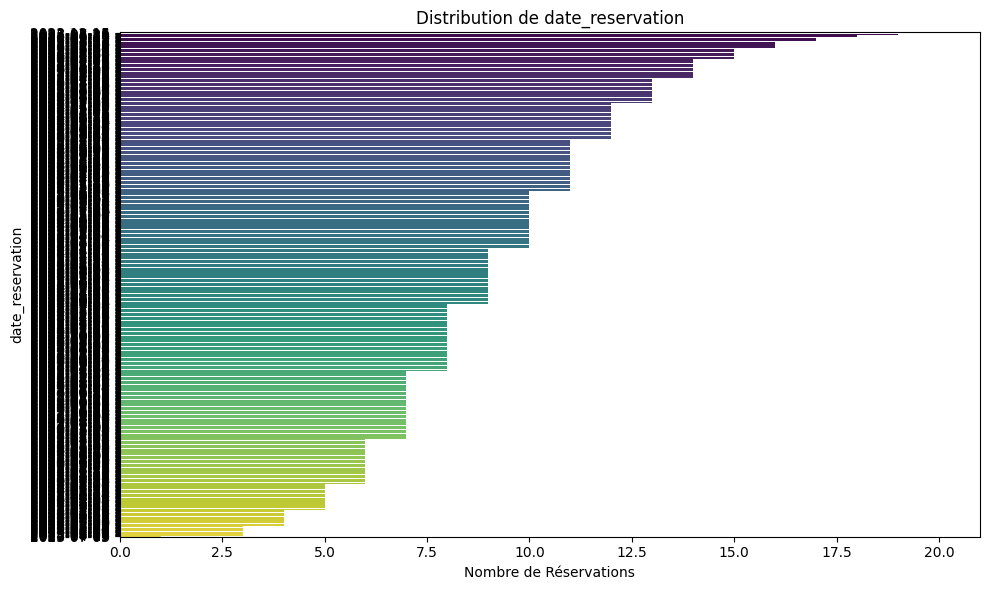

/tmp/ipykernel_1065/2965392459.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_reservations[col], order=df_reservations[col].value_counts().index, palette='viridis')


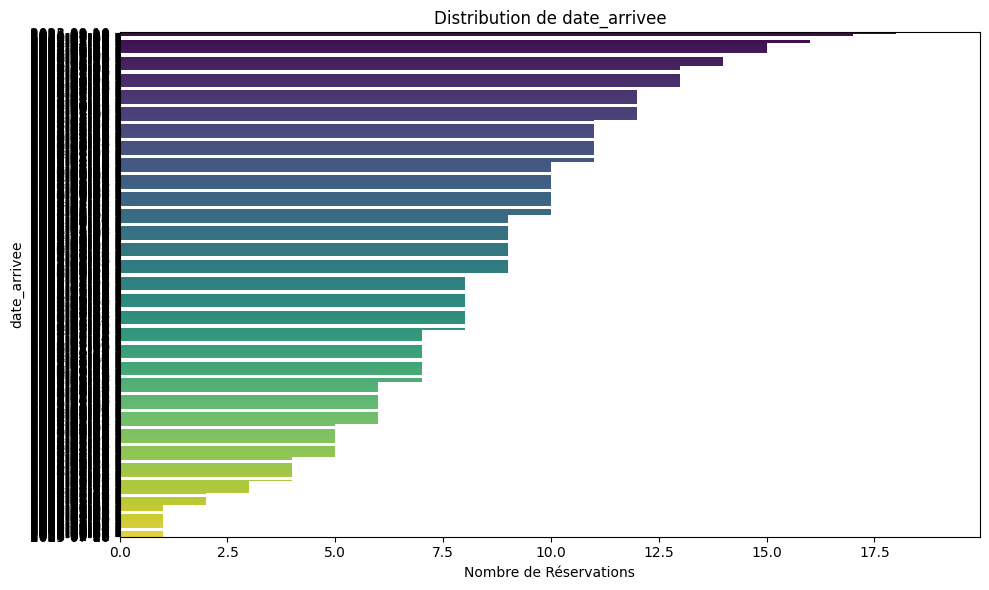

/tmp/ipykernel_1065/2965392459.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_reservations[col], order=df_reservations[col].value_counts().index, palette='viridis')


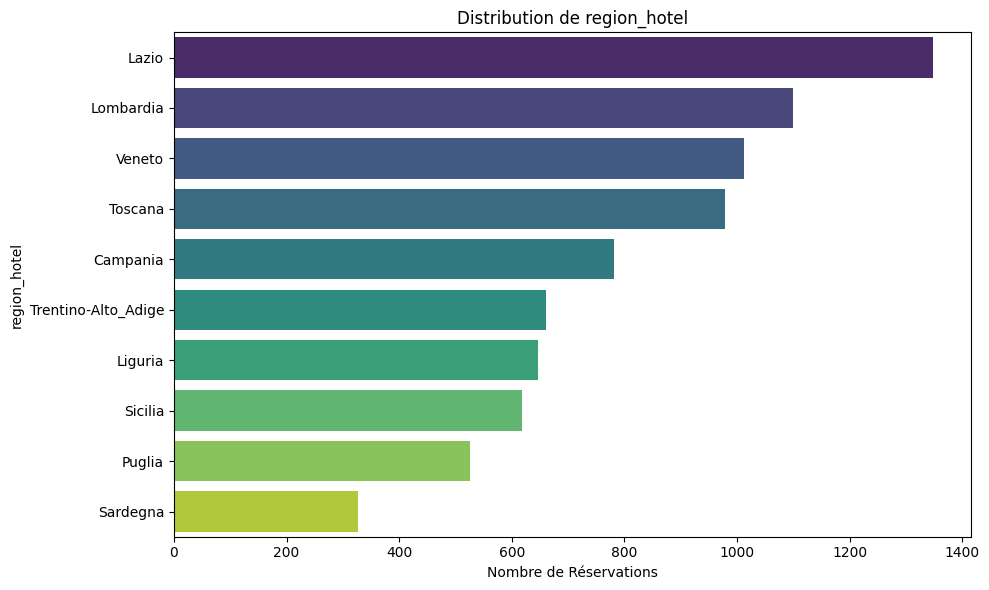

/tmp/ipykernel_1065/2965392459.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_reservations[col], order=df_reservations[col].value_counts().index, palette='viridis')


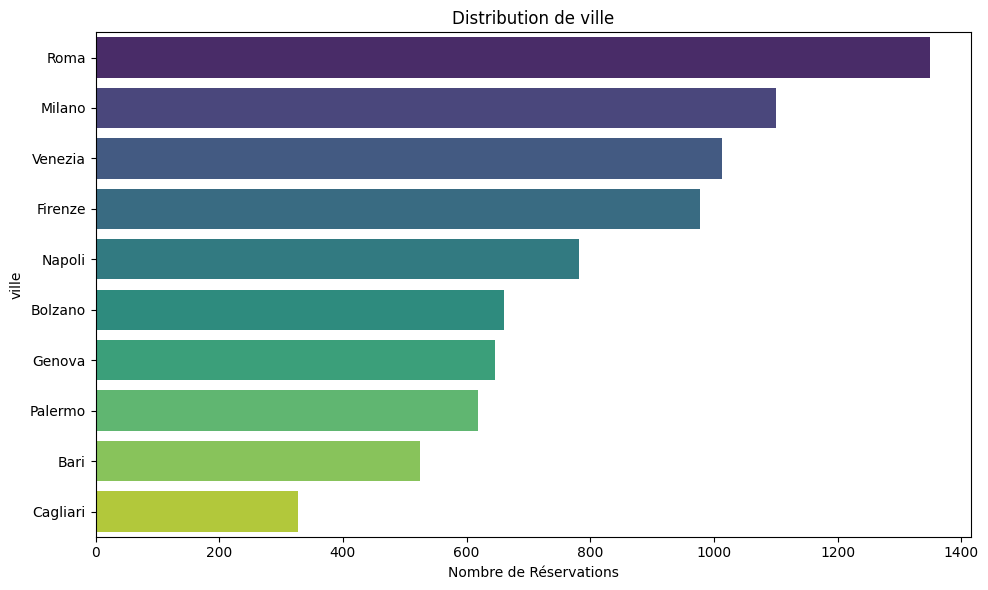

/tmp/ipykernel_1065/2965392459.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_reservations[col], order=df_reservations[col].value_counts().index, palette='viridis')


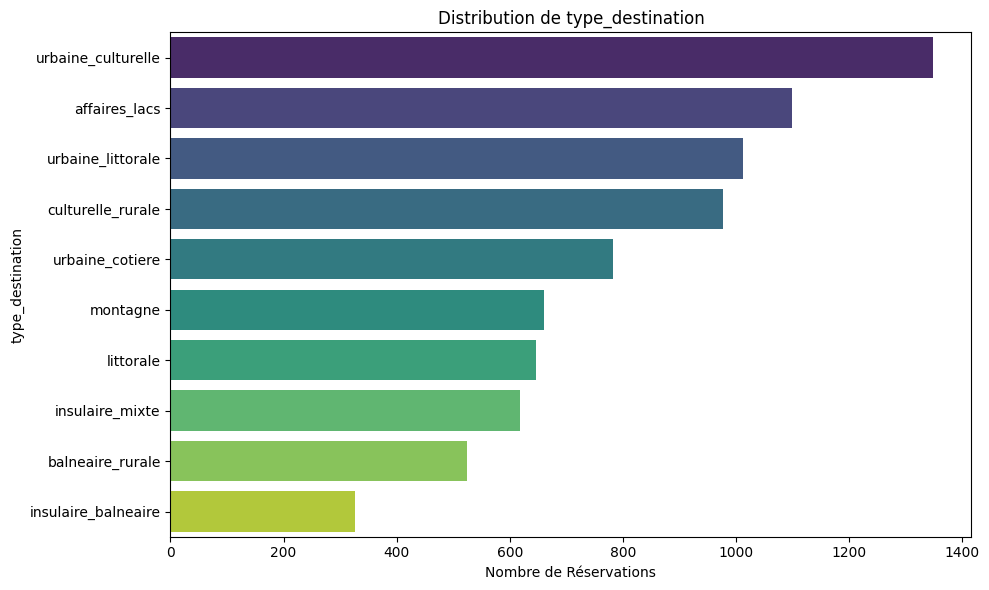

/tmp/ipykernel_1065/2965392459.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_reservations[col], order=df_reservations[col].value_counts().index, palette='viridis')


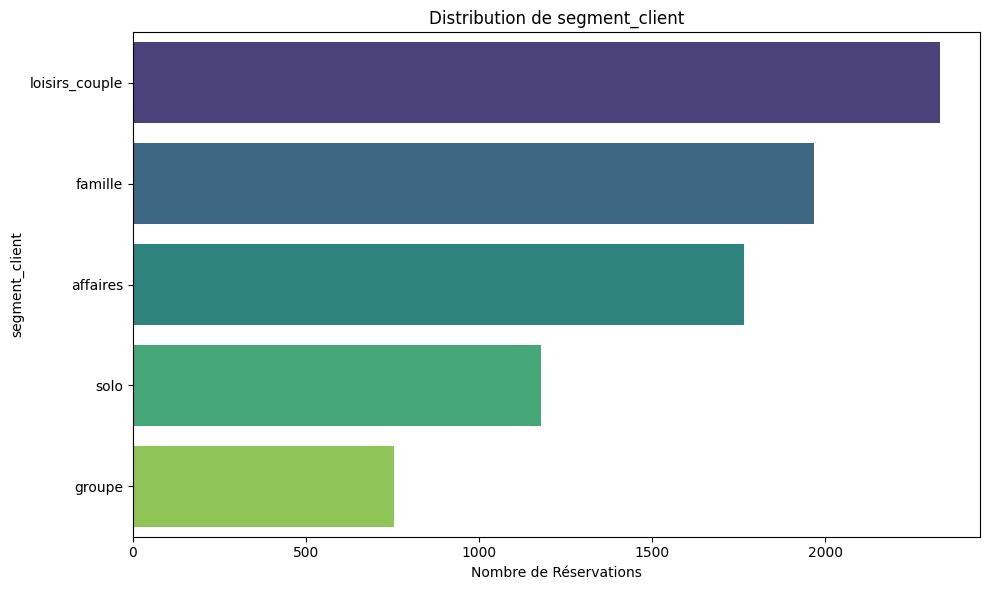

/tmp/ipykernel_1065/2965392459.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_reservations[col], order=df_reservations[col].value_counts().index, palette='viridis')


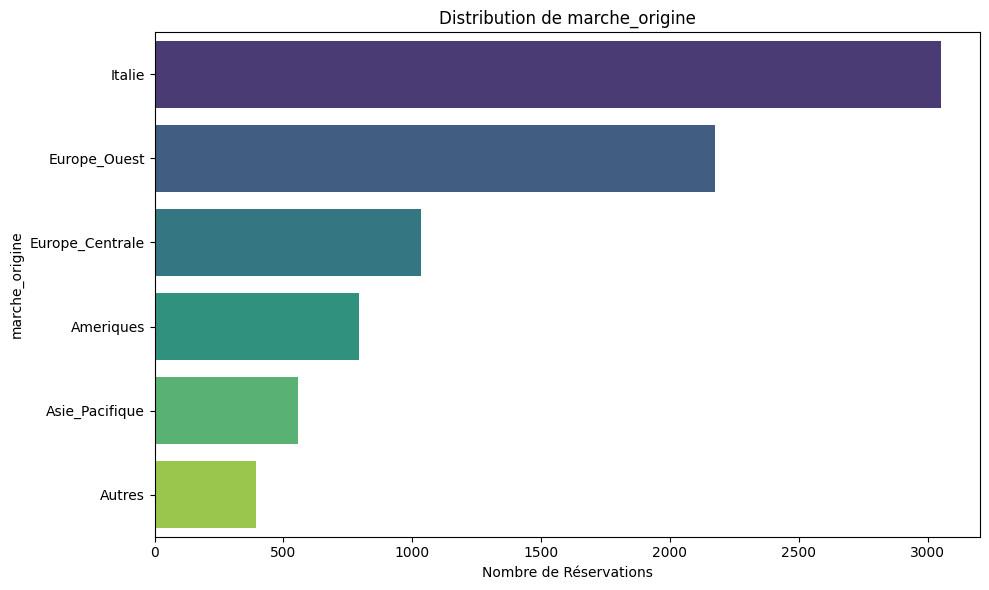

/tmp/ipykernel_1065/2965392459.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_reservations[col], order=df_reservations[col].value_counts().index, palette='viridis')


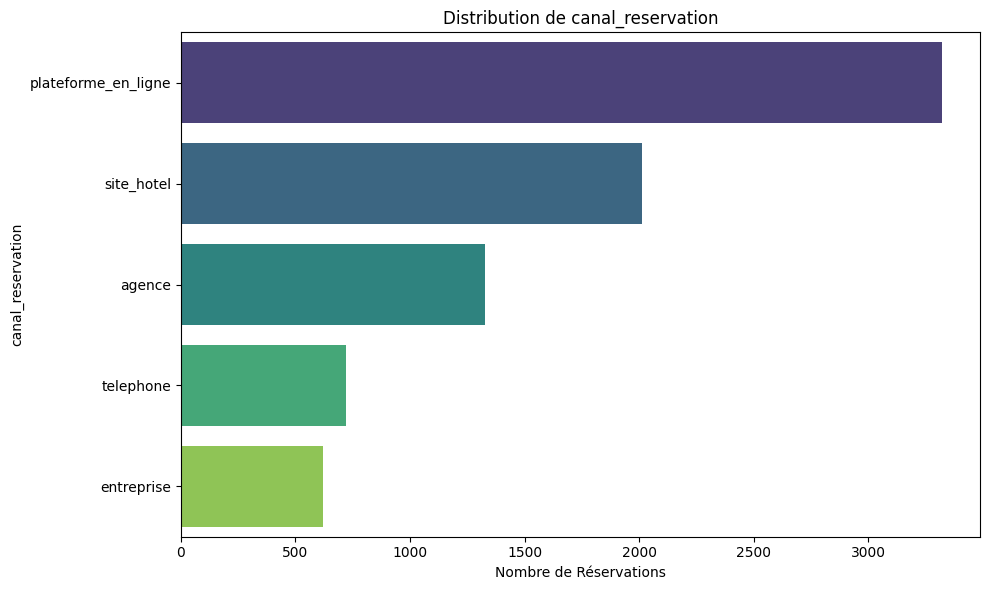

/tmp/ipykernel_1065/2965392459.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_reservations[col], order=df_reservations[col].value_counts().index, palette='viridis')


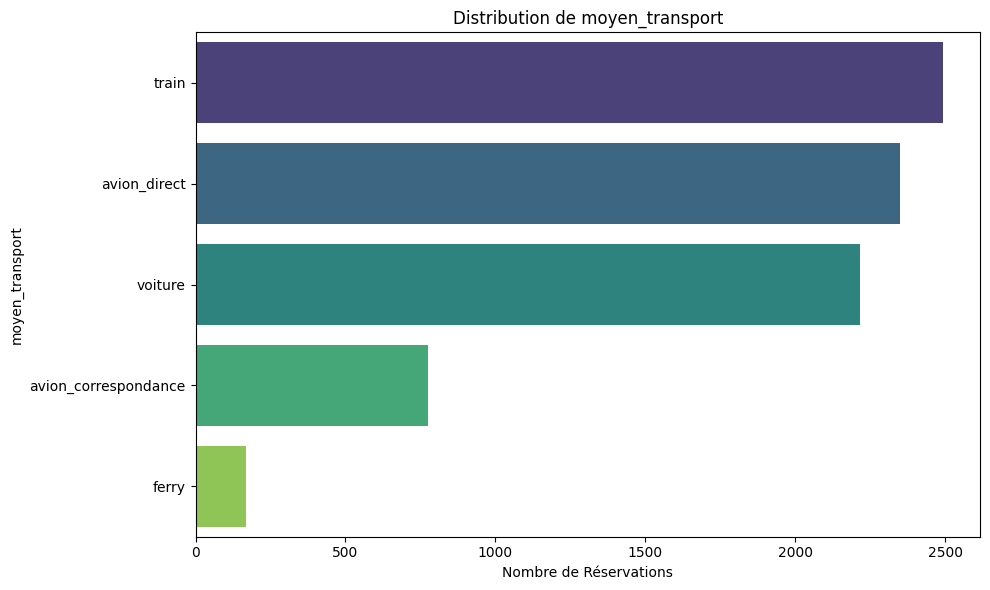

/tmp/ipykernel_1065/2965392459.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_reservations[col], order=df_reservations[col].value_counts().index, palette='viridis')


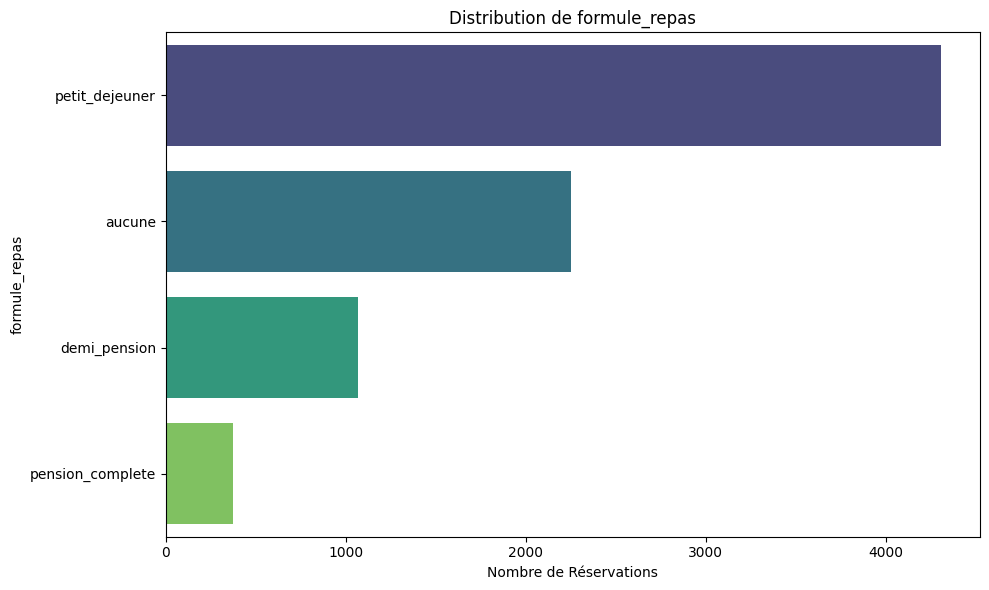

/tmp/ipykernel_1065/2965392459.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_reservations[col], order=df_reservations[col].value_counts().index, palette='viridis')


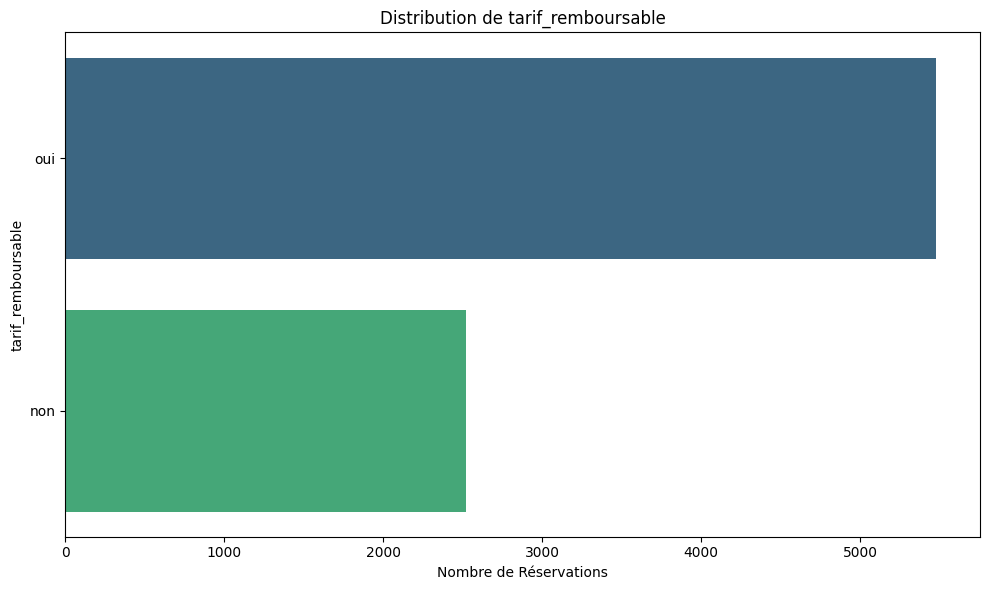

/tmp/ipykernel_1065/2965392459.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_reservations[col], order=df_reservations[col].value_counts().index, palette='viridis')


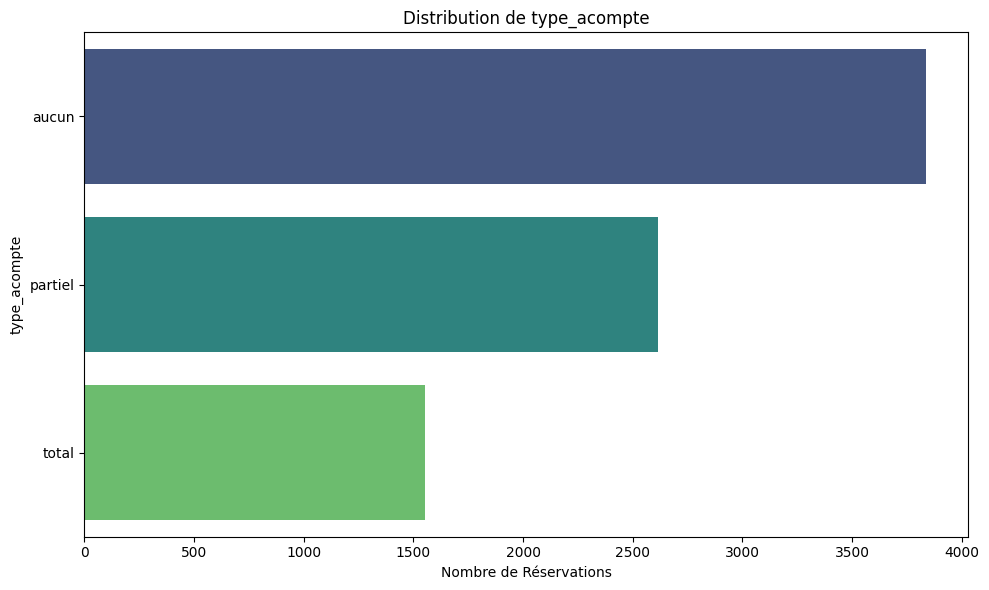

/tmp/ipykernel_1065/2965392459.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_reservations[col], order=df_reservations[col].value_counts().index, palette='viridis')


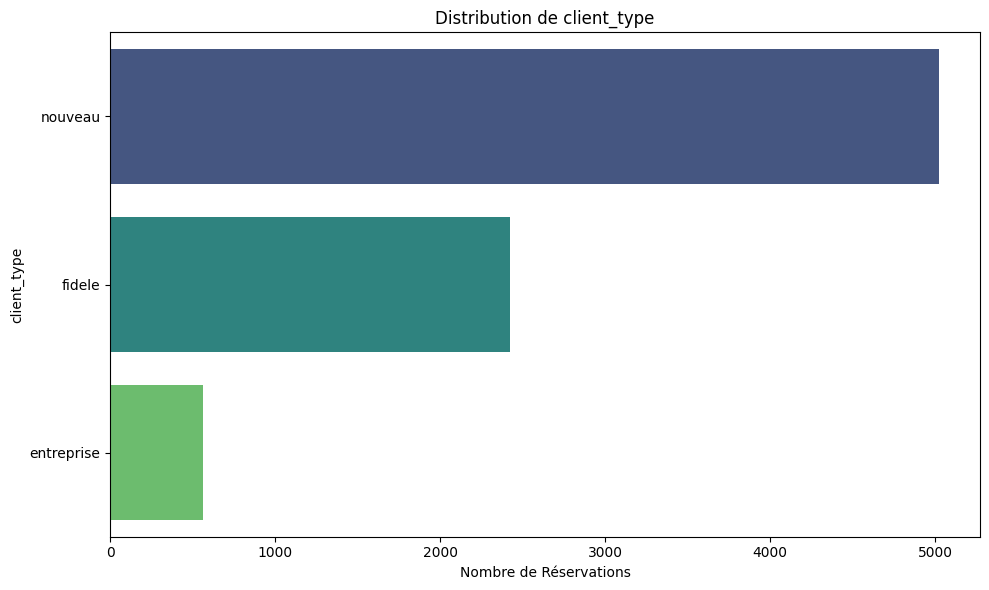

/tmp/ipykernel_1065/2965392459.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_reservations[col], order=df_reservations[col].value_counts().index, palette='viridis')


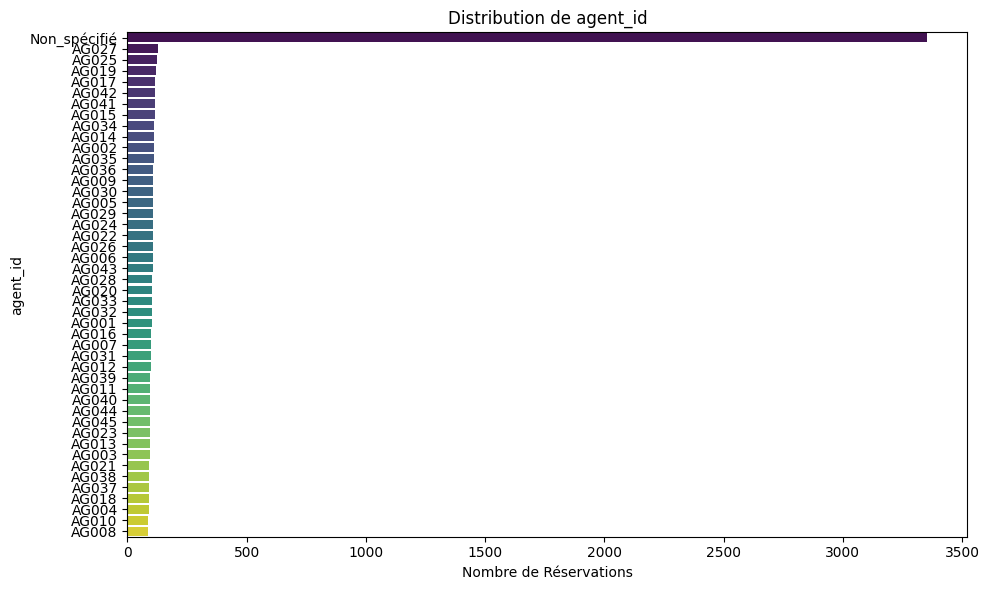

/tmp/ipykernel_1065/2965392459.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_reservations[col], order=df_reservations[col].value_counts().index, palette='viridis')


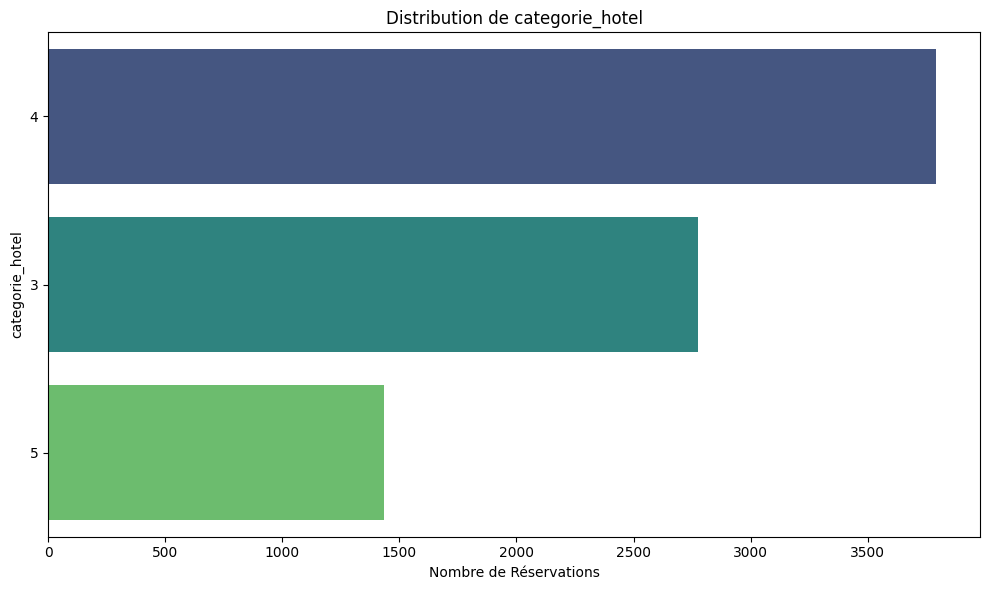

/tmp/ipykernel_1065/2965392459.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_reservations[col], order=df_reservations[col].value_counts().index, palette='viridis')


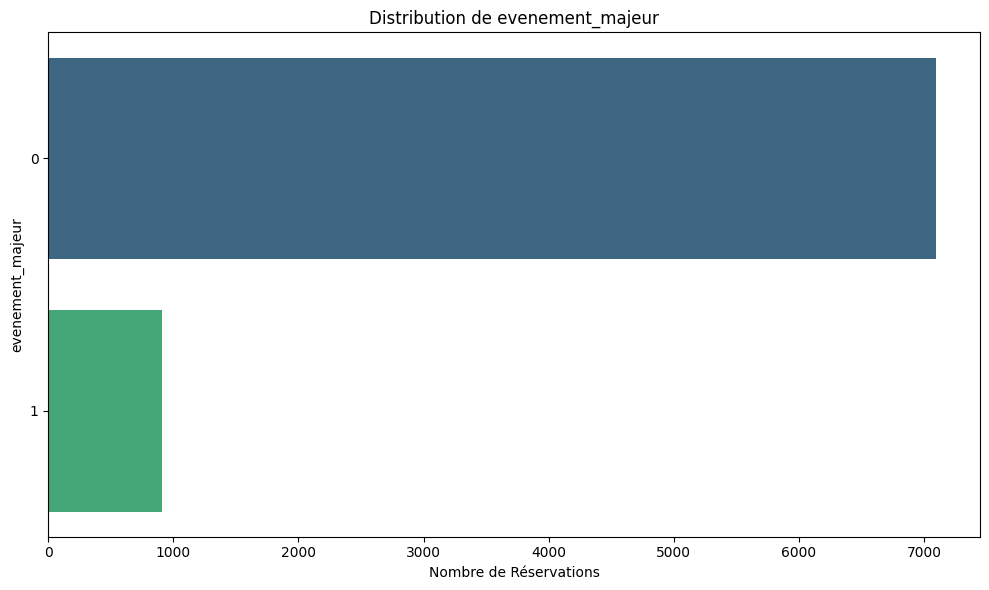

/tmp/ipykernel_1065/2965392459.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_reservations[col], order=df_reservations[col].value_counts().index, palette='viridis')


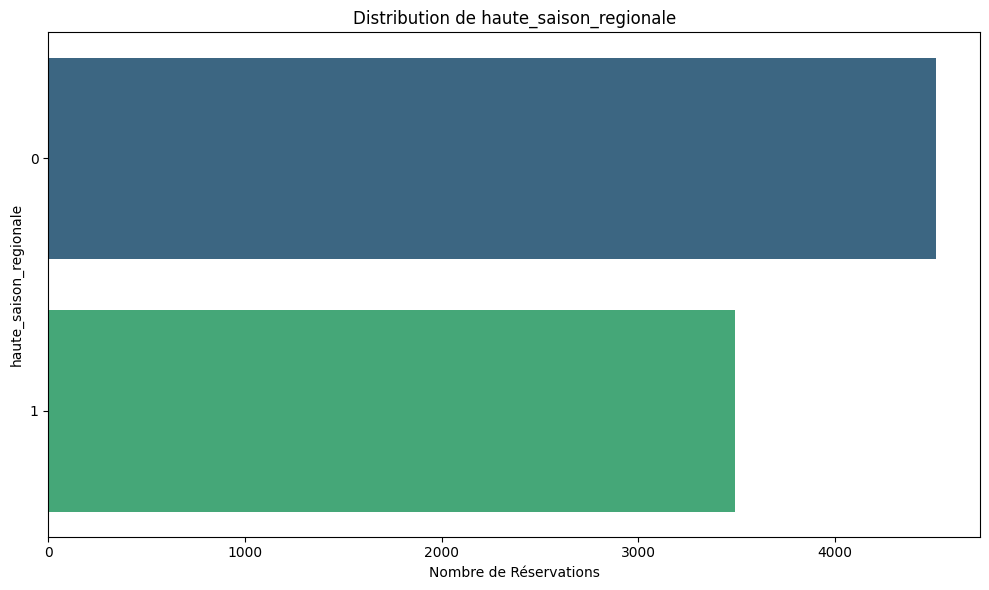

/tmp/ipykernel_1065/2965392459.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_reservations[col], order=df_reservations[col].value_counts().index, palette='viridis')


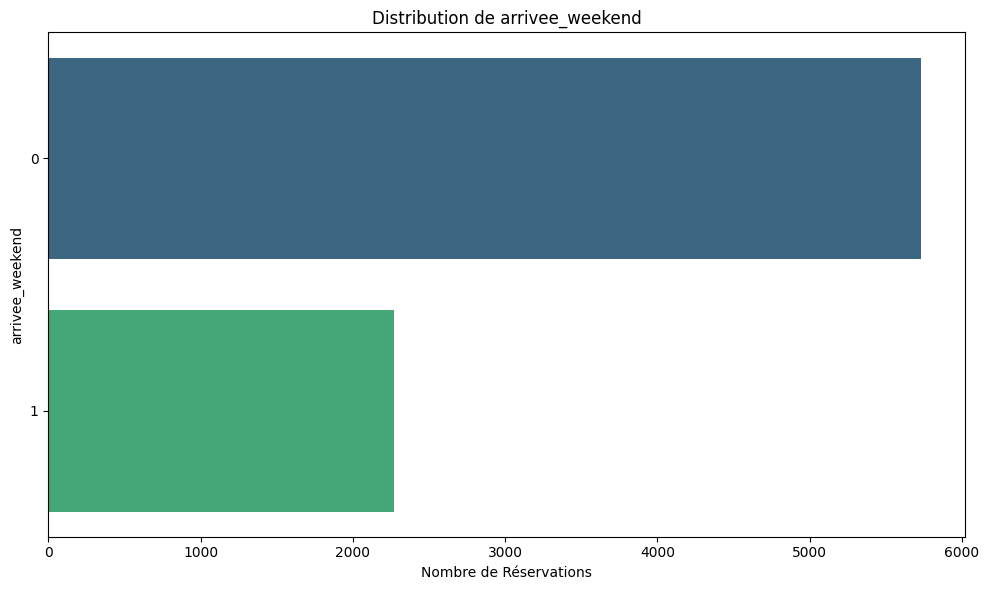

In [ ]:
# Identifier les colonnes catégorielles (incluant les 'object' et les int64/float64 avec peu de valeurs uniques, comme les indicateurs)
categorical_cols = df_reservations.select_dtypes(include='object').columns.tolist()

# Ajouter les colonnes binaires/quasi-catégorielles exclues précédemment
categorical_cols.extend(['categorie_hotel', 'evenement_majeur', 'haute_saison_regionale', 'arrivee_weekend'])

# Exclure les IDs qui n'apportent pas d'information catégorielle utile pour la distribution
categorical_cols = [col for col in categorical_cols if col not in ['reservation_id', 'hotel_id']]

for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(y=df_reservations[col], order=df_reservations[col].value_counts().index, palette='viridis')
    plt.title(f'Distribution de {col}')
    plt.xlabel('Nombre de Réservations')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

#### Analyse des Relations Temporelles

Maintenant que nous avons extrait les caractéristiques temporelles, nous allons les analyser pour comprendre leur distribution et leur relation avec la variable cible `reservation_annulee`.

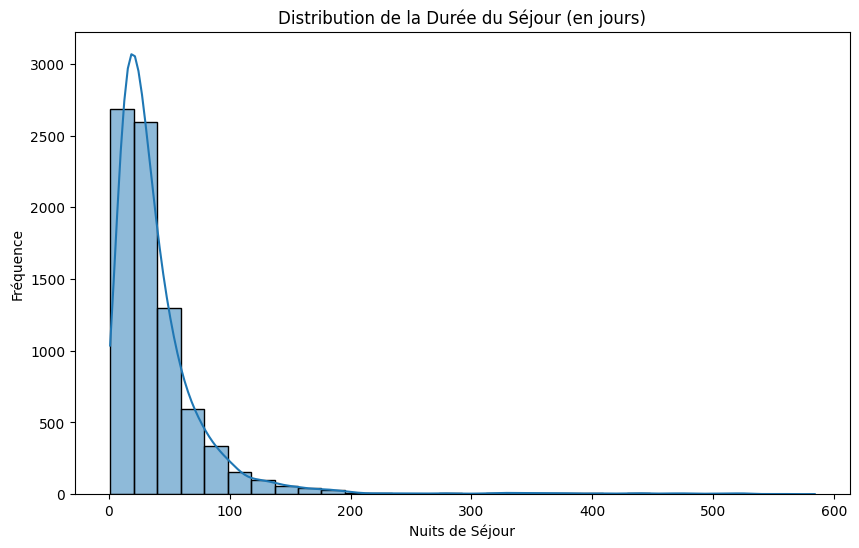

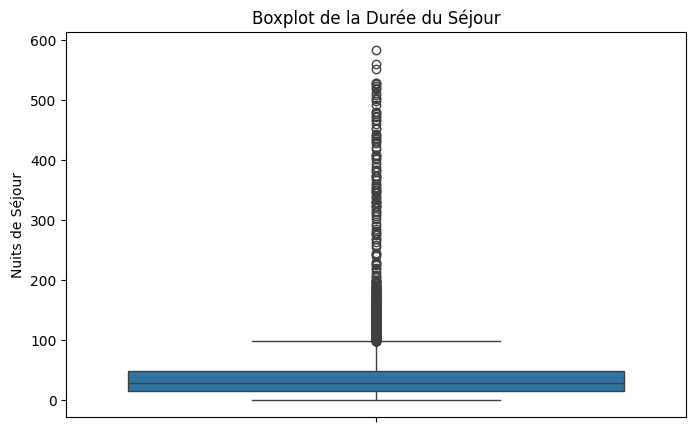

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution de la durée du séjour (nuits_sejour)
plt.figure(figsize=(10, 6))
sns.histplot(df_reservations['nuits_sejour'], kde=True, bins=30)
plt.title('Distribution de la Durée du Séjour (en jours)')
plt.xlabel('Nuits de Séjour')
plt.ylabel('Fréquence')
plt.show()

# Boxplot pour identifier les outliers dans la durée du séjour
plt.figure(figsize=(8, 5))
sns.boxplot(y=df_reservations['nuits_sejour'])
plt.title('Boxplot de la Durée du Séjour')
plt.ylabel('Nuits de Séjour')
plt.show()

##### Impact du Jour de la Semaine de Réservation sur les Annulations

/tmp/ipykernel_1065/219971414.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='res_jour_semaine', y='reservation_annulee', data=res_jour_semaine_cancel_rate, palette='viridis')


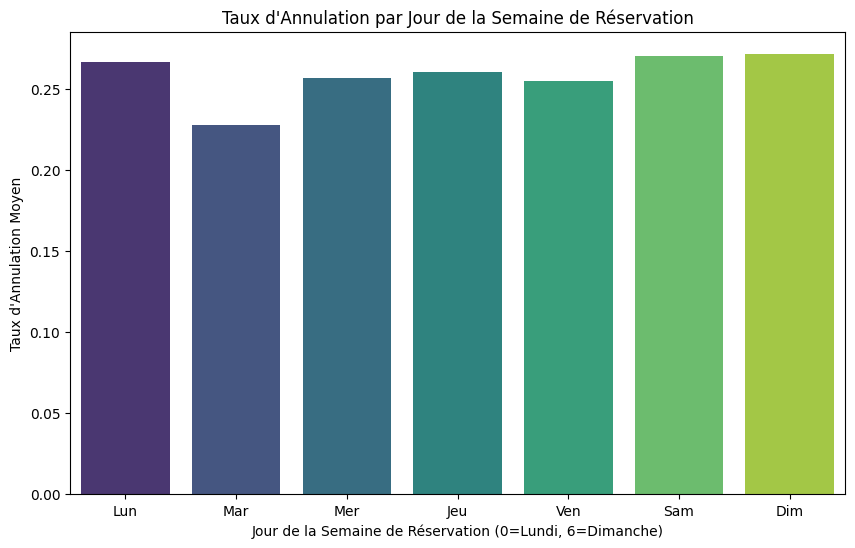

In [ ]:
# Analyse de l'impact du jour de la semaine de réservation sur les annulations
res_jour_semaine_cancel_rate = df_reservations.groupby('res_jour_semaine')['reservation_annulee'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='res_jour_semaine', y='reservation_annulee', data=res_jour_semaine_cancel_rate, palette='viridis')
plt.title('Taux d\'Annulation par Jour de la Semaine de Réservation')
plt.xlabel('Jour de la Semaine de Réservation (0=Lundi, 6=Dimanche)')
plt.ylabel('Taux d\'Annulation Moyen')
plt.xticks(ticks=range(7), labels=['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim'])
plt.show()

##### Impact du Jour de la Semaine d'Arrivée sur les Annulations

/tmp/ipykernel_1065/3220517019.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='arr_jour_semaine', y='reservation_annulee', data=arr_jour_semaine_cancel_rate, palette='viridis')


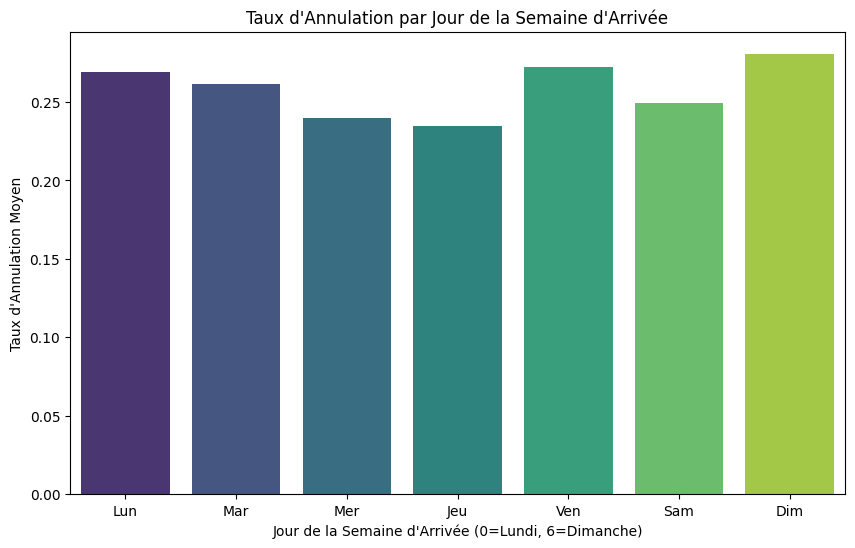

In [ ]:
# Analyse de l'impact du jour de la semaine d'arrivée sur les annulations
arr_jour_semaine_cancel_rate = df_reservations.groupby('arr_jour_semaine')['reservation_annulee'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='arr_jour_semaine', y='reservation_annulee', data=arr_jour_semaine_cancel_rate, palette='viridis')
plt.title('Taux d\'Annulation par Jour de la Semaine d\'Arrivée')
plt.xlabel('Jour de la Semaine d\'Arrivée (0=Lundi, 6=Dimanche)')
plt.ylabel('Taux d\'Annulation Moyen')
plt.xticks(ticks=range(7), labels=['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim'])
plt.show()

##### Impact du Mois de Réservation sur les Annulations

/tmp/ipykernel_1065/379711218.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='res_mois', y='reservation_annulee', data=res_mois_cancel_rate, palette='viridis')


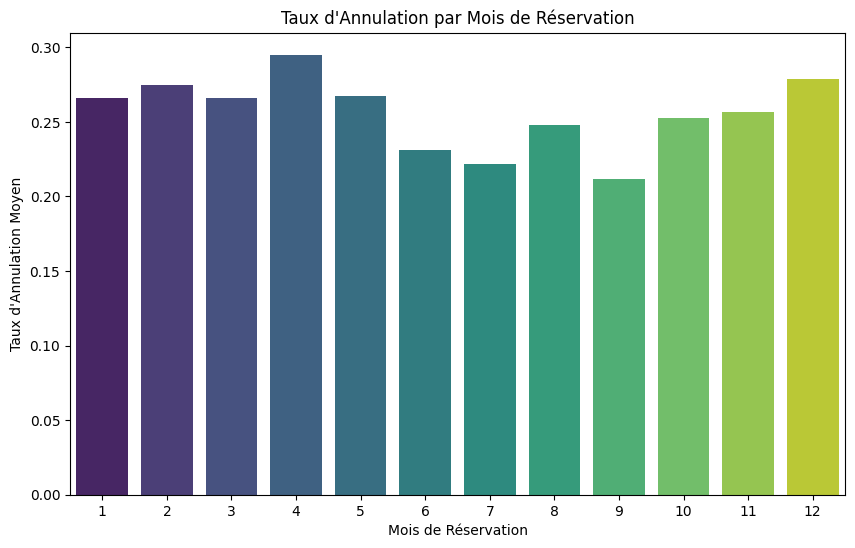

In [ ]:
# Analyse de l'impact du mois de réservation sur les annulations
res_mois_cancel_rate = df_reservations.groupby('res_mois')['reservation_annulee'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='res_mois', y='reservation_annulee', data=res_mois_cancel_rate, palette='viridis')
plt.title('Taux d\'Annulation par Mois de Réservation')
plt.xlabel('Mois de Réservation')
plt.ylabel('Taux d\'Annulation Moyen')
plt.show()

##### Impact du Mois d'Arrivée sur les Annulations

/tmp/ipykernel_1065/3368054511.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='arr_mois', y='reservation_annulee', data=arr_mois_cancel_rate, palette='viridis')


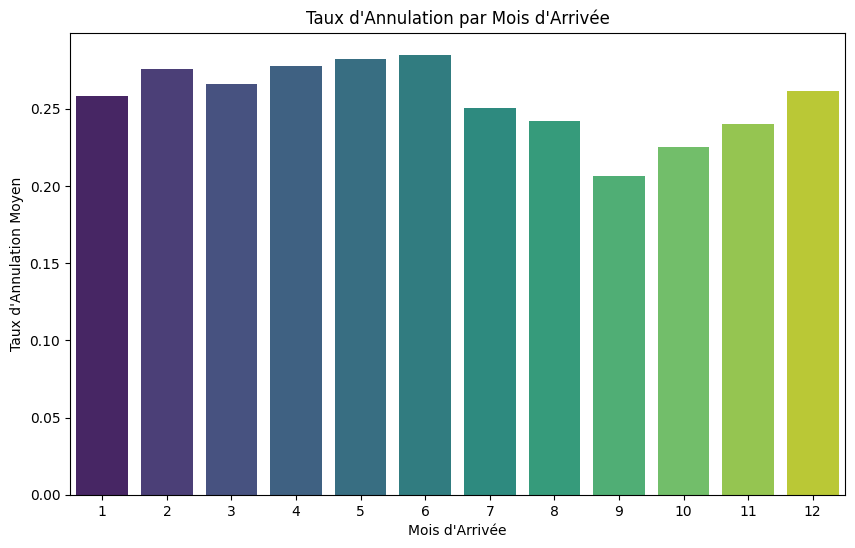

In [ ]:
# Analyse de l'impact du mois d'arrivée sur les annulations
arr_mois_cancel_rate = df_reservations.groupby('arr_mois')['reservation_annulee'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='arr_mois', y='reservation_annulee', data=arr_mois_cancel_rate, palette='viridis')
plt.title('Taux d\'Annulation par Mois d\'Arrivée')
plt.xlabel('Mois d\'Arrivée')
plt.ylabel('Taux d\'Annulation Moyen')
plt.show()

### Ingénierie des Caractéristiques (Feature Engineering)

Nous allons créer de nouvelles variables à partir des données existantes pour potentiellement améliorer la performance de notre modèle et capturer des informations plus fines.

#### 1. Caractéristiques issues des Dates

Nous allons extraire le jour de la semaine, le mois et l'année à partir des colonnes `date_reservation` et `date_arrivee`. Nous allons également calculer la durée du séjour (`nuits_sejour`) et le délai entre la réservation et l'arrivée (`delai_reservation_en_jours`).

In [ ]:
# Convertir les colonnes de date au format datetime si ce n'est pas déjà fait
# Cela évite l'AttributeError: Can only use .dt accessor with datetimelike values
import pandas as pd

if not pd.api.types.is_datetime64_any_dtype(df_reservations['date_reservation']):
    df_reservations['date_reservation'] = pd.to_datetime(df_reservations['date_reservation'])
if not pd.api.types.is_datetime64_any_dtype(df_reservations['date_arrivee']):
    df_reservations['date_arrivee'] = pd.to_datetime(df_reservations['date_arrivee'])

# Créer des caractéristiques temporelles à partir de 'date_reservation'
df_reservations['res_jour_semaine'] = df_reservations['date_reservation'].dt.dayofweek
df_reservations['res_mois'] = df_reservations['date_reservation'].dt.month
df_reservations['res_annee'] = df_reservations['date_reservation'].dt.year

# Créer des caractéristiques temporelles à partir de 'date_arrivee'
df_reservations['arr_jour_semaine'] = df_reservations['date_arrivee'].dt.dayofweek
df_reservations['arr_mois'] = df_reservations['date_arrivee'].dt.month
df_reservations['arr_annee'] = df_reservations['date_arrivee'].dt.year

# Calculer la durée du séjour en jours
df_reservations['nuits_sejour'] = (df_reservations['date_arrivee'] - df_reservations['date_reservation']).dt.days

# Vérifier les premières lignes avec les nouvelles caractéristiques
print("DataFrame avec les nouvelles caractéristiques temporelles (extrait) :")
display(df_reservations[['date_reservation', 'date_arrivee', 'res_jour_semaine', 'res_mois', 'res_annee', 'arr_jour_semaine', 'arr_mois', 'arr_annee', 'nuits_sejour']].head())

DataFrame avec les nouvelles caractéristiques temporelles (extrait) :


,date_reservation,date_arrivee,res_jour_semaine,res_mois,res_annee,arr_jour_semaine,arr_mois,arr_annee,nuits_sejour
0,2023-01-01,2023-03-13,6,1,2023,0,3,2023,71
1,2023-01-01,2023-01-07,6,1,2023,5,1,2023,6
2,2023-01-01,2023-03-26,6,1,2023,6,3,2023,84
3,2023-01-01,2023-01-09,6,1,2023,0,1,2023,8
4,2023-01-01,2023-01-11,6,1,2023,2,1,2023,10


#### 2. Création d'indicateurs et autres caractéristiques

Nous allons créer un indicateur pour les clients récurrents et d'autres caractéristiques agrégées.

In [ ]:
# Indicateur de client récurrent
df_reservations['client_recurrent'] = ((df_reservations['reservations_passees'] > 0) | (df_reservations['annulations_passees'] > 0)).astype(int)

# Ratio d'annulation passée
df_reservations['ratio_annulation_passee'] = df_reservations['annulations_passees'] / (df_reservations['reservations_passees'] + df_reservations['annulations_passees'] + 1e-6) # Ajouter un petit epsilon pour éviter division par zéro

# Ratio enfants par adultes
df_reservations['ratio_enfants_adultes'] = df_reservations['enfants'] / (df_reservations['adultes'] + 1e-6)

# Vérifier les nouvelles colonnes
print("DataFrame avec les nouvelles caractéristiques (extrait) :")
display(df_reservations[['reservations_passees', 'annulations_passees', 'client_recurrent', 'ratio_annulation_passee', 'enfants', 'adultes', 'ratio_enfants_adultes']].head())

DataFrame avec les nouvelles caractéristiques (extrait) :


,reservations_passees,annulations_passees,client_recurrent,ratio_annulation_passee,enfants,adultes,ratio_enfants_adultes
0,0,0,0,0.0,0.0,2,0.0
1,9,1,1,0.1,1.0,2,0.5
2,0,0,0,0.0,0.0,2,0.0
3,0,0,0,0.0,1.0,2,0.5
4,0,0,0,0.0,0.0,2,0.0


#### 3. Encodage des Variables Catégorielles

Pour préparer les données à la modélisation, nous devons convertir les variables catégorielles (non numériques) en un format numérique. Nous allons utiliser l'encodage One-Hot (One-Hot Encoding) pour les colonnes catégorielles identifiées.

In [ ]:
import pandas as pd

# Identifier les colonnes catégorielles restantes à encoder
# Exclure les colonnes de date qui ont déjà été traitées ou ne sont plus nécessaires en tant qu'objets
# Exclure les colonnes numériques, binaires déjà prêtes ou la cible

categorical_cols_to_encode = df_reservations.select_dtypes(include='object').columns.tolist()

# Ajouter les colonnes qui ont été traitées comme catégorielles précédemment
categorical_cols_to_encode.extend(['categorie_hotel', 'evenement_majeur', 'haute_saison_regionale', 'arrivee_weekend'])

# Exclure les colonnes ID et les caractéristiques qui ont déjà été créées/utilisées sous forme numérique
# ou celles que nous ne voulons pas encoder (ex: date_reservation, date_arrivee sont maintenant datetime et utilisées pour des features)
exclude_cols = ['reservation_id', 'hotel_id', 'date_reservation', 'date_arrivee']

# Filtrer la liste finale
categorical_cols_to_encode = [col for col in categorical_cols_to_encode if col not in exclude_cols]

print(f"Colonnes catégorielles à encoder: {categorical_cols_to_encode}")

# Appliquer One-Hot Encoding
df_reservations_encoded = pd.get_dummies(df_reservations, columns=categorical_cols_to_encode, drop_first=True)

print("\nDataFrame après encodage One-Hot (extrait) :")
display(df_reservations_encoded.head())

print(f"\nNouvelles dimensions du DataFrame: {df_reservations_encoded.shape}")

Colonnes catégorielles à encoder: ['region_hotel', 'ville', 'type_destination', 'segment_client', 'marche_origine', 'canal_reservation', 'moyen_transport', 'formule_repas', 'tarif_remboursable', 'type_acompte', 'client_type', 'agent_id', 'categorie_hotel', 'evenement_majeur', 'haute_saison_regionale', 'arrivee_weekend']

DataFrame après encodage One-Hot (extrait) :


,reservation_id,date_reservation,date_arrivee,hotel_id,delai_reservation_jours,nuits,adultes,enfants,chambres,prix_moyen_nuit_eur,...,agent_id_AG042,agent_id_AG043,agent_id_AG044,agent_id_AG045,agent_id_Non_spécifié,categorie_hotel_4,categorie_hotel_5,evenement_majeur_1,haute_saison_regionale_1,arrivee_weekend_1
0,R000808,2023-01-01,2023-03-13,CAM-4-2,71,4,2,0.0,1,165.72,...,False,False,False,False,False,True,False,False,False,False
1,R001808,2023-01-01,2023-01-07,LAZ-4-3,6,3,2,1.0,1,187.00,...,False,False,False,False,False,True,False,False,False,True
2,R002130,2023-01-01,2023-03-26,LOM-4-2,84,3,2,0.0,1,180.61,...,False,True,False,False,False,True,False,False,False,False
3,R003635,2023-01-01,2023-01-09,LIG-4-1,8,3,2,1.0,1,202.10,...,False,False,False,False,False,True,False,True,False,False
4,R004683,2023-01-01,2023-01-11,SAR-3-2,10,4,2,0.0,1,138.89,...,False,False,False,False,True,False,False,False,False,False



Nouvelles dimensions du DataFrame: (8000, 130)


#### 4. Division des Données et Mise à l'Échelle

Avant de passer à la modélisation, nous devons diviser nos données en ensembles d'entraînement et de test, puis mettre à l'échelle les caractéristiques numériques. La mise à l'échelle est cruciale pour les algorithmes sensibles à l'amplitude des données.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Séparer les caractéristiques (X) et la variable cible (y)
X = df_reservations_encoded.drop('reservation_annulee', axis=1)
y = df_reservations_encoded['reservation_annulee']

# Exclure les colonnes non pertinentes de X (IDs et colonnes de dates originales)
X = X.drop(columns=['reservation_id', 'hotel_id', 'date_reservation', 'date_arrivee'], errors='ignore')

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Dimensions de X_train : {X_train.shape}")
print(f"Dimensions de X_test : {X_test.shape}")
print(f"Dimensions de y_train : {y_train.shape}")
print(f"Dimensions de y_test : {y_test.shape}")

Dimensions de X_train : (6400, 125)
Dimensions de X_test : (1600, 125)
Dimensions de y_train : (6400,)
Dimensions de y_test : (1600,)


##### Mise à l'Échelle des Caractéristiques Numériques

Nous allons identifier les colonnes numériques restantes (qui ne sont pas des variables binaires issues de l'encodage One-Hot) et leur appliquer une mise à l'échelle `StandardScaler`.

In [ ]:
# Identifier les colonnes numériques pour la mise à l'échelle
# Celles-ci sont les colonnes float ou int qui ne sont PAS des dummies ou des colonnes 'dt' créées.

# Obtenir les noms de toutes les colonnes numériques non-binaires
numerical_cols_for_scaling = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Supprimer les colonnes qui sont binaires (0/1) ou sont déjà mises à l'échelle implicitement (ex: les colonnes des jours/mois/années)
# Pour ce faire, nous pouvons exclure les colonnes qui ont très peu de valeurs uniques ou sont des booléens après get_dummies

binary_or_dummy_cols = [col for col in numerical_cols_for_scaling if X_train[col].nunique() <= 2]

# On conserve uniquement les colonnes numériques continues pour le scaling
numerical_cols_to_scale = [col for col in numerical_cols_for_scaling if col not in binary_or_dummy_cols]

print(f"Colonnes numériques à mettre à l'échelle : {numerical_cols_to_scale}")

# Appliquer StandardScaler
scaler = StandardScaler()
X_train[numerical_cols_to_scale] = scaler.fit_transform(X_train[numerical_cols_to_scale])
X_test[numerical_cols_to_scale] = scaler.transform(X_test[numerical_cols_to_scale])

print("\nDataFrame d'entraînement après mise à l'échelle (extrait) :")
display(X_train.head())

print("\nDataFrame de test après mise à l'échelle (extrait) :")
display(X_test.head())

Colonnes numériques à mettre à l'échelle : ['delai_reservation_jours', 'nuits', 'adultes', 'enfants', 'chambres', 'prix_moyen_nuit_eur', 'remise_pct', 'montant_total_eur', 'reservations_passees', 'annulations_passees', 'demandes_speciales', 'modifications_reservation', 'jours_liste_attente', 'ratio_annulation_passee', 'ratio_enfants_adultes', 'nuits_sejour']

DataFrame d'entraînement après mise à l'échelle (extrait) :


,delai_reservation_jours,nuits,adultes,enfants,chambres,prix_moyen_nuit_eur,remise_pct,montant_total_eur,reservations_passees,annulations_passees,...,agent_id_AG042,agent_id_AG043,agent_id_AG044,agent_id_AG045,agent_id_Non_spécifié,categorie_hotel_4,categorie_hotel_5,evenement_majeur_1,haute_saison_regionale_1,arrivee_weekend_1
5551,-0.693802,0.314677,-0.095762,-0.544139,-0.405617,-0.154486,-0.555793,0.102355,-0.639445,-0.56599,...,False,False,False,False,False,True,False,False,True,False
7527,1.249564,1.512023,-1.180502,-0.544139,-0.405617,-0.586390,0.815266,0.233546,-0.639445,-0.56599,...,False,False,False,False,True,False,False,False,True,False
6021,0.267864,1.112908,-0.095762,-0.544139,-0.405617,-0.399745,0.815266,0.143585,-0.639445,-0.56599,...,False,False,False,False,True,False,False,False,True,True
5510,-0.373246,-0.483553,-1.180502,-0.544139,-0.405617,-0.050357,0.266842,-0.519481,-0.639445,-0.56599,...,False,False,False,False,False,True,False,False,True,True
2962,-0.313142,1.112908,-0.095762,0.530704,-0.405617,0.426408,-0.007369,0.570260,-0.639445,-0.56599,...,False,False,False,False,False,False,True,True,False,False



DataFrame de test après mise à l'échelle (extrait) :


,delai_reservation_jours,nuits,adultes,enfants,chambres,prix_moyen_nuit_eur,remise_pct,montant_total_eur,reservations_passees,annulations_passees,...,agent_id_AG042,agent_id_AG043,agent_id_AG044,agent_id_AG045,agent_id_Non_spécifié,categorie_hotel_4,categorie_hotel_5,evenement_majeur_1,haute_saison_regionale_1,arrivee_weekend_1
1390,-0.152865,-0.882668,-0.095762,0.530704,-0.405617,0.299031,3.283171,-0.741824,-0.639445,-0.565990,...,False,False,False,False,True,True,False,False,True,False
7646,0.207760,1.112908,-1.180502,-0.544139,-0.405617,1.056583,0.541054,0.820758,1.475243,2.752689,...,False,False,False,False,False,False,False,True,True,False
6010,0.267864,0.713793,-0.095762,-0.544139,-0.405617,-1.154186,-0.281581,-0.297802,0.682235,1.093349,...,False,False,False,False,False,False,False,False,False,False
7198,-0.613663,0.314677,-0.095762,-0.544139,-0.405617,-0.098328,0.541054,-0.120331,-0.639445,-0.565990,...,False,False,False,False,False,False,True,False,False,False
1498,-0.273073,0.314677,-0.095762,-0.544139,-0.405617,-0.413170,1.637901,-0.262972,-0.639445,-0.565990,...,False,False,False,False,True,False,False,False,True,False


### Ingénierie des Caractéristiques (Feature Engineering)

Nous allons créer de nouvelles variables à partir des données existantes pour potentiellement améliorer la performance de notre modèle et capturer des informations plus fines.

#### 1. Caractéristiques issues des Dates

Nous allons extraire le jour de la semaine, le mois et l'année à partir des colonnes `date_reservation` et `date_arrivee`. Nous allons également calculer la durée du séjour (`nuits_sejour`) et le délai entre la réservation et l'arrivée (`delai_reservation_en_jours`).

In [ ]:
# Créer des caractéristiques temporelles à partir de 'date_reservation'
df_reservations['res_jour_semaine'] = df_reservations['date_reservation'].dt.dayofweek
df_reservations['res_mois'] = df_reservations['date_reservation'].dt.month
df_reservations['res_annee'] = df_reservations['date_reservation'].dt.year

# Créer des caractéristiques temporelles à partir de 'date_arrivee'
df_reservations['arr_jour_semaine'] = df_reservations['date_arrivee'].dt.dayofweek
df_reservations['arr_mois'] = df_reservations['date_arrivee'].dt.month
df_reservations['arr_annee'] = df_reservations['date_arrivee'].dt.year

# Calculer la durée du séjour en jours
df_reservations['nuits_sejour'] = (df_reservations['date_arrivee'] - df_reservations['date_reservation']).dt.days

# Vérifier les premières lignes avec les nouvelles caractéristiques
print("DataFrame avec les nouvelles caractéristiques temporelles (extrait) :")
display(df_reservations[['date_reservation', 'date_arrivee', 'res_jour_semaine', 'res_mois', 'res_annee', 'arr_jour_semaine', 'arr_mois', 'arr_annee', 'nuits_sejour']].head())

AttributeError: Can only use .dt accessor with datetimelike values

#### 2. Création d'indicateurs et autres caractéristiques

Nous allons créer un indicateur pour les clients récurrents et d'autres caractéristiques agrégées.

In [ ]:
# Indicateur de client récurrent
df_reservations['client_recurrent'] = ((df_reservations['reservations_passees'] > 0) | (df_reservations['annulations_passees'] > 0)).astype(int)

# Ratio d'annulation passée
df_reservations['ratio_annulation_passee'] = df_reservations['annulations_passees'] / (df_reservations['reservations_passees'] + df_reservations['annulations_passees'] + 1e-6) # Ajouter un petit epsilon pour éviter division par zéro

# Ratio enfants par adultes
df_reservations['ratio_enfants_adultes'] = df_reservations['enfants'] / (df_reservations['adultes'] + 1e-6)

# Vérifier les nouvelles colonnes
print("DataFrame avec les nouvelles caractéristiques (extrait) :")
display(df_reservations[['reservations_passees', 'annulations_passees', 'client_recurrent', 'ratio_annulation_passee', 'enfants', 'adultes', 'ratio_enfants_adultes']].head())

DataFrame avec les nouvelles caractéristiques (extrait) :


,reservations_passees,annulations_passees,client_recurrent,ratio_annulation_passee,enfants,adultes,ratio_enfants_adultes
0,0,0,0,0.0,0.0,2,0.0
1,9,1,1,0.1,1.0,2,0.5
2,0,0,0,0.0,0.0,2,0.0
3,0,0,0,0.0,1.0,2,0.5
4,0,0,0,0.0,0.0,2,0.0
